# Predicting the stock market with Machine Learning and Python

# 1. Libraries

In [74]:
# Import necessary libraries and packages.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols

# Finance Data.
import yfinance as yf
import time as time

# ML libraries.
from sklearn.ensemble import RandomForestClassifier

# 2. Functions library

In [50]:
def validate_data(df):
    #check for unique values
    unique_counts = df.nunique()
    print("Unique values per column:")
    print(unique_counts)
    
    #checking for duplicates
    duplicate_count = df.duplicated().sum()
    print("\nNumber of duplicate rows:")
    print(duplicate_count)
    
    #summary stats
    summary_stats = df.describe()
    print("\nSummary statistics:")
    print(summary_stats)
    
    return unique_counts, duplicate_count, summary_stats

#Example usage - validate_data(df)

In [54]:
def extract_object_values(df, column_name):
    """
    Extracts and prints all unique values from an object column in a DataFrame.

    :param df: pandas DataFrame
    :param column_name: Name of the object column to extract values from
    """
    if column_name in df.columns and df[column_name].dtype == 'O':  # 'O' stands for object type
        values_list = df[column_name].dropna().unique().tolist()
        return values_list
    else:
        print(f"Column '{column_name}' is either missing or not of object type.")

# Example usage:
# df = pd.DataFrame({'col1': [1, 2, 3], 'col2': ['apple', 'banana', 'apple']})
# extract_object_values(df, 'col2')

# 3. Data wrangling and cleaning

In [41]:
# Initialise a ticker class to download data for a single symbol.
# Example using S&P 500.
sp500 = yf.Ticker("^GSPC")
nvda = yf.Ticker("NVDA")

In [12]:
# Query the historical prices using history method.
sp500 = sp500.history(period='max')

In [14]:
sp500.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-24 00:00:00-04:00,5381.379883,5489.399902,5371.959961,5484.770020,4697710000,0.0,0.0
2025-04-25 00:00:00-04:00,5489.729980,5528.109863,5455.859863,5525.209961,4236580000,0.0,0.0
2025-04-28 00:00:00-04:00,5529.220215,5553.660156,5468.640137,5528.750000,4257880000,0.0,0.0
2025-04-29 00:00:00-04:00,5508.870117,5571.950195,5505.700195,5560.830078,4747150000,0.0,0.0
2025-04-30 00:00:00-04:00,5499.439941,5499.439941,5433.240234,5490.950195,873916133,0.0,0.0


In [43]:
# Query the historical prices using the history method. 
nvda = nvda.history(period='max')

In [45]:
nvda

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1999-01-22 00:00:00-05:00,0.040119,0.044775,0.035581,0.037612,2714688000,0.0,0.0
1999-01-25 00:00:00-05:00,0.040597,0.042029,0.037612,0.041552,510480000,0.0,0.0
1999-01-26 00:00:00-05:00,0.042029,0.042865,0.037731,0.038328,343200000,0.0,0.0
1999-01-27 00:00:00-05:00,0.038447,0.039403,0.036298,0.038209,244368000,0.0,0.0
1999-01-28 00:00:00-05:00,0.038209,0.038447,0.037850,0.038089,227520000,0.0,0.0
...,...,...,...,...,...,...,...
2025-04-24 00:00:00-04:00,103.480003,106.540001,103.110001,106.430000,220815000,0.0,0.0
2025-04-25 00:00:00-04:00,106.849998,111.919998,105.730003,111.010002,251064700,0.0,0.0
2025-04-28 00:00:00-04:00,109.690002,110.370003,106.019997,108.730003,207708500,0.0,0.0


## Cleaning and visualising the data.

<Axes: xlabel='Date'>

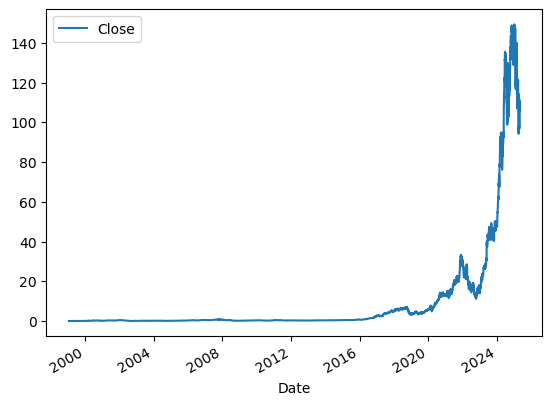

In [28]:
# Plotting data, closing price against the index (Date).
nvda.plot.line(y="Close", use_index=True)

In [52]:
# Validate the stock market data.
validate_data(nvda)

Unique values per column:
Open            6592
High            6581
Low             6572
Close           5566
Volume          6525
Dividends          9
Stock Splits       5
dtype: int64

Number of duplicate rows:
0

Summary statistics:
              Open         High          Low        Close        Volume  \
count  6609.000000  6609.000000  6609.000000  6609.000000  6.609000e+03   
mean      9.582076     9.761643     9.381635     9.579491  5.967971e+08   
std      25.577235    26.050116    25.012050    25.547723  4.299607e+08   
min       0.032000     0.032597     0.030566     0.031283  1.968000e+07   
25%       0.258594     0.265930     0.251697     0.259129  3.353640e+08   
50%       0.439720     0.445397     0.433283     0.439449  4.980640e+08   
75%       4.799877     4.889864     4.728641     4.828539  7.284120e+08   
max     153.015919   153.115916   147.806407   149.416245  9.230856e+09   

         Dividends  Stock Splits  
count  6609.000000   6609.000000  
mean      0.000029

(Open            6592
 High            6581
 Low             6572
 Close           5566
 Volume          6525
 Dividends          9
 Stock Splits       5
 dtype: int64,
 0,
               Open         High          Low        Close        Volume  \
 count  6609.000000  6609.000000  6609.000000  6609.000000  6.609000e+03   
 mean      9.582076     9.761643     9.381635     9.579491  5.967971e+08   
 std      25.577235    26.050116    25.012050    25.547723  4.299607e+08   
 min       0.032000     0.032597     0.030566     0.031283  1.968000e+07   
 25%       0.258594     0.265930     0.251697     0.259129  3.353640e+08   
 50%       0.439720     0.445397     0.433283     0.439449  4.980640e+08   
 75%       4.799877     4.889864     4.728641     4.828539  7.284120e+08   
 max     153.015919   153.115916   147.806407   149.416245  9.230856e+09   
 
          Dividends  Stock Splits  
 count  6609.000000   6609.000000  
 mean      0.000029      0.003253  
 std       0.000377      0.140358

In [59]:
# Remove the columns that won't be used for analysis.
del nvda["Dividends"]
del nvda["Stock Splits"]

In [61]:
# View the Data.
nvda

,Open,High,Low,Close,Volume
Date,,,,,
1999-01-22 00:00:00-05:00,0.040119,0.044775,0.035581,0.037612,2714688000
1999-01-25 00:00:00-05:00,0.040597,0.042029,0.037612,0.041552,510480000
1999-01-26 00:00:00-05:00,0.042029,0.042865,0.037731,0.038328,343200000
1999-01-27 00:00:00-05:00,0.038447,0.039403,0.036298,0.038209,244368000
1999-01-28 00:00:00-05:00,0.038209,0.038447,0.037850,0.038089,227520000
...,...,...,...,...,...
2025-04-24 00:00:00-04:00,103.480003,106.540001,103.110001,106.430000,220815000
2025-04-25 00:00:00-04:00,106.849998,111.919998,105.730003,111.010002,251064700
2025-04-28 00:00:00-04:00,109.690002,110.370003,106.019997,108.730003,207708500


## EDA

In [70]:
# Simple moving average (SMA). 
# Calcularw 20-day SMA
nvda['SMA_20'] = nvda['Close'].rolling(window=20).mean()

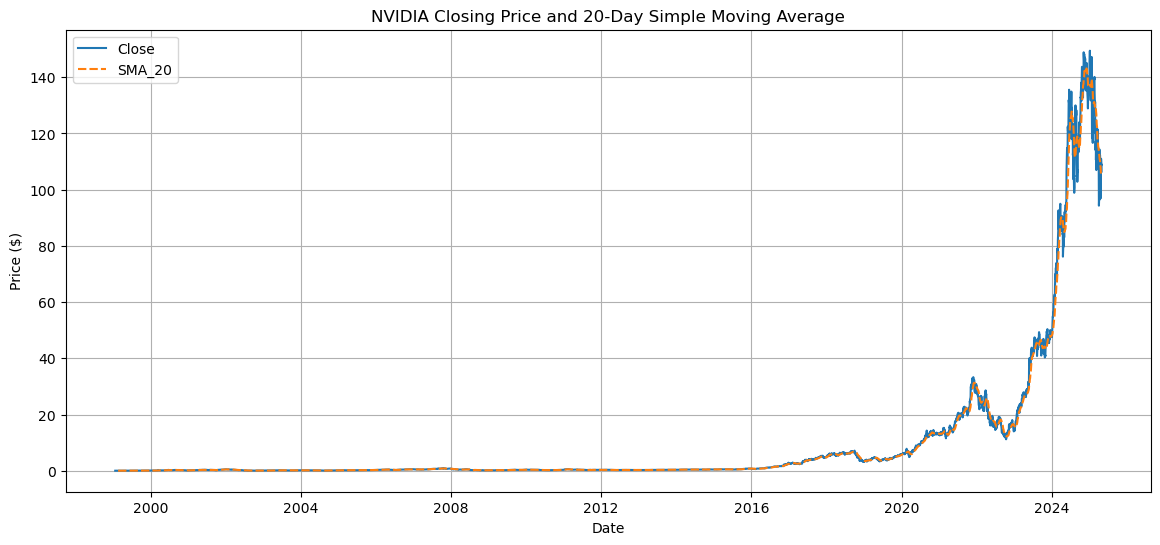

In [76]:
# Plot the closing price and SMA in seaborn.
plt.figure(figsize=(14,6))
sns.lineplot(data=nvda[['Close','SMA_20']])
plt.title("NVIDIA Closing Price and 20-Day Simple Moving Average")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [84]:
# Exponential moving average (EMA). 
# Calculate 20-dayEMA
nvda['EMA_20'] = nvda['Close'].ewm(span=20, adjust = False).mean()

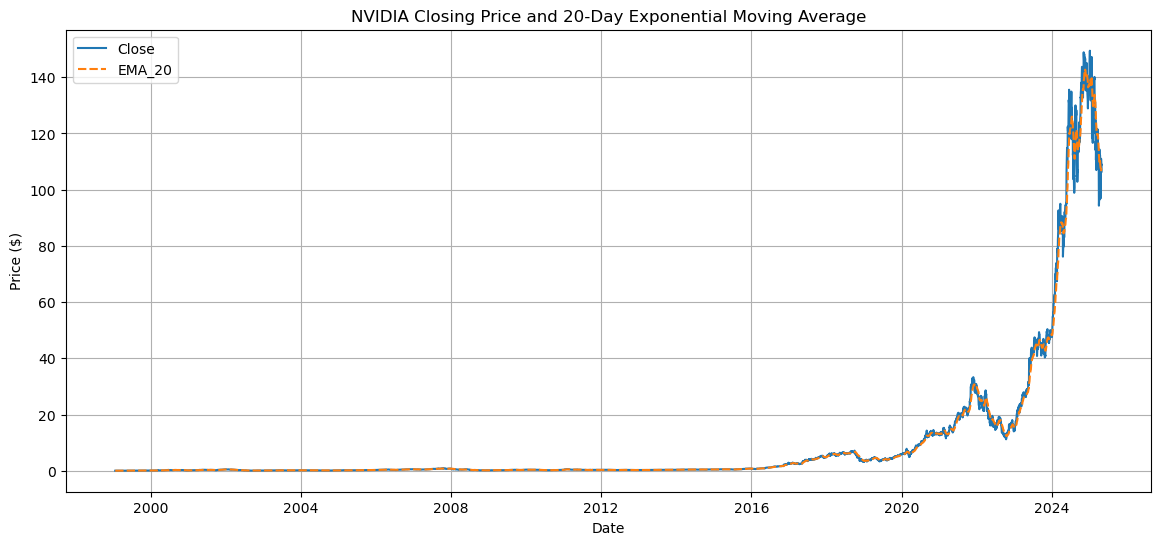

In [86]:
# Plot the closing price and EMA in seaborn.
plt.figure(figsize=(14, 6))
sns.lineplot(data=nvda[['Close', 'EMA_20']])
plt.title("NVIDIA Closing Price and 20-Day Exponential Moving Average")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

# Data Wrangling for ML model.

In [49]:
# Setting up the target - will the price go up or down tomorrow? 
# [1] Establish a Tomorrow column - The close on the following day. 
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [51]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2025-04-16 00:00:00-04:00,5335.750000,5367.240234,5220.790039,5275.700195,4607750000,5282.700195
2025-04-17 00:00:00-04:00,5305.450195,5328.310059,5255.580078,5282.700195,4714880000,5158.200195
2025-04-21 00:00:00-04:00,5232.939941,5232.939941,5101.629883,5158.200195,4226340000,5287.759766


In [53]:
# Set up the target column - 1 when price goes up and 0 when the price goes down. 
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [55]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2025-04-16 00:00:00-04:00,5335.750000,5367.240234,5220.790039,5275.700195,4607750000,5282.700195,1
2025-04-17 00:00:00-04:00,5305.450195,5328.310059,5255.580078,5282.700195,4714880000,5158.200195,0
2025-04-21 00:00:00-04:00,5232.939941,5232.939941,5101.629883,5158.200195,4226340000,5287.759766,1


In [57]:
# With Stockmarket data, some historical data may not be useful, as the stockmarket has fundamentally changed.
# Remove all data pre-1990.
sp500 = sp500.loc['1990-01-01':].copy()

In [59]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2025-04-16 00:00:00-04:00,5335.750000,5367.240234,5220.790039,5275.700195,4607750000,5282.700195,1
2025-04-17 00:00:00-04:00,5305.450195,5328.310059,5255.580078,5282.700195,4714880000,5158.200195,0
2025-04-21 00:00:00-04:00,5232.939941,5232.939941,5101.629883,5158.200195,4226340000,5287.759766,1


In [65]:
# Training the initial ML model.
# Initialise the model.
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

# You need to take the time series data into account, as we want the model to learn how to predict the stock price.
# We can't just randomly select a proportion of our sample to know how to predict the stock price.
# We put all of the rows except the last 100 into the training set.
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

# Set the columns we want to use in the models. 
predictors = ["Close", "Volume", "High","Low"]

# Fit the model.
model.fit(train[predictors], train["Target"])


RandomForestClassifier(min_samples_split=100, random_state=1)

In [67]:
# Measure how accurate the model is. 
from sklearn.metrics import precision_score
preds = model.predict(test[predictors])

In [69]:
# Turn the preds into a dataframe. 
import pandas as pd
preds = pd.Series(preds, index=test.index)

In [71]:
preds

Date
2024-11-26 00:00:00-05:00    1
2024-11-27 00:00:00-05:00    1
2024-11-29 00:00:00-05:00    1
2024-12-02 00:00:00-05:00    1
2024-12-03 00:00:00-05:00    1
                            ..
2025-04-16 00:00:00-04:00    1
2025-04-17 00:00:00-04:00    1
2025-04-21 00:00:00-04:00    0
2025-04-22 00:00:00-04:00    1
2025-04-23 00:00:00-04:00    1
Length: 100, dtype: int64

In [73]:
# Calculate the precision score, using actual and predicted scores. 
precision_score(test["Target"], preds)

0.4787234042553192

A poor prediction score, we would be losing money. We will attempt to make the model more performant.

In [77]:
# Plot our prediction combine the predicted values with the actual values. Using conctat.
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

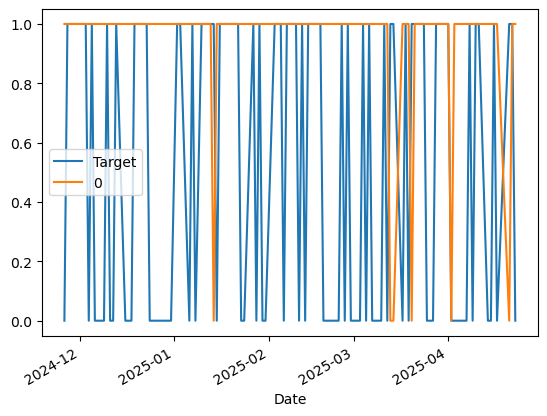

In [79]:
combined.plot()

The model mostly predicted the market would go up, while it was far more varied. We need a more robust way to test. We need to be able to test across multiple years of data, to have more confidence it will work in the future. We will backtest, by creating a prediction function. 

In [85]:
def predict (train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds=pd.Series(preds, index = test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [87]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range (start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [89]:
predictions = backtest(sp500, model, predictors)

In [91]:
predictions["Predictions"].value_counts()

Predictions
0    3642
1    2751
Name: count, dtype: int64

In [95]:
precision_score(predictions["Target"], predictions["Predictions"])

0.529989094874591

In [97]:
predictions["Target"].value_counts() / predictions.shape[0]

Target
1    0.535742
0    0.464258
Name: count, dtype: float64

The model still does worse than just buying at market open and selling at market close. We need to add some more predictors to our model.

In [102]:
# Create a variety of rolling averages. Is the stockmarket higher than it was last week, a month ago etc...
# We are giving the algorythm some more information to create predictions.
horizons = [2, 5, 60, 250, 1000]
new_predictors = []

# We loop these horizons and create a rolling average.
for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]  # Close price in our sp500 divided by the rolling average.

    trend_column = f"Trend+{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [104]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend+2,Close_Ratio_5,Trend+5,Close_Ratio_60,Trend+60,Close_Ratio_250,Trend+250,Close_Ratio_1000,Trend+1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-16 00:00:00-04:00,5335.750000,5367.240234,5220.790039,5275.700195,4607750000,5282.700195,1,0.988669,0.0,0.987600,2.0,0.913219,29.0,0.932760,142.0,1.132047,525.0
2025-04-17 00:00:00-04:00,5305.450195,5328.310059,5255.580078,5282.700195,4714880000,5158.200195,0,1.000663,1.0,0.988368,3.0,0.916556,29.0,0.933819,143.0,1.133282,525.0
2025-04-21 00:00:00-04:00,5232.939941,5232.939941,5101.629883,5158.200195,4226340000,5287.759766,1,0.988076,1.0,0.972541,2.0,0.897447,28.0,0.911688,143.0,1.106343,525.0


In [106]:
# Remove additional rows.
sp500 = sp500.dropna()

In [108]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend+2,Close_Ratio_5,Trend+5,Close_Ratio_60,Trend+60,Close_Ratio_250,Trend+250,Close_Ratio_1000,Trend+1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-15 00:00:00-04:00,5411.990234,5450.410156,5386.439941,5396.629883,4317110000,5275.700195,0,0.999135,1.0,1.003430,3.0,0.932071,30.0,0.954312,142.0,1.158268,526.0
2025-04-16 00:00:00-04:00,5335.750000,5367.240234,5220.790039,5275.700195,4607750000,5282.700195,1,0.988669,0.0,0.987600,2.0,0.913219,29.0,0.932760,142.0,1.132047,525.0
2025-04-17 00:00:00-04:00,5305.450195,5328.310059,5255.580078,5282.700195,4714880000,5158.200195,0,1.000663,1.0,0.988368,3.0,0.916556,29.0,0.933819,143.0,1.133282,525.0


In [110]:
# Now update the model slightly to include the new parameters. 
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [112]:
def predict (train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds>= .6] = 1
    preds[preds < .6] = 0
    preds=pd.Series(preds, index = test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [114]:
predictions = backtest(sp500, model, new_predictors)

In [116]:
predictions["Predictions"].value_counts()

Predictions
0.0    4526
1.0     866
Name: count, dtype: int64

In [120]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5739030023094688

The model beats the market baseline and can be considered to have some predictive value.

Summary:
We downloaded, cleaned and visualised the data. 
we created a model.
We then improved our model.

How could we extend this model. 
Is there an index on the other side of the world, that is increasing, does that help predict the sp500 better. 
You can add in news, inflation, other macroeconomic information.
Is tech in a downturn or has it been in a downturn previously? That might influence the results in 6 months time. Are there indicator stocks. 

You can build a number of different factors into the model.
